In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# 1. Đọc dữ liệu (Đảm bảo file csv nằm cùng thư mục)
df = pd.read_csv('housing_data_cleaned_v3.csv')

# 2. Tạo biến mục tiêu: Tổng giá trị căn nhà (Total Price)
# Chiến thuật: Dự đoán tổng giá sẽ chính xác hơn dự đoán đơn giá/m2
df['total_price'] = df['squared_meter_area'] * df['price_in_million_per_square_meter']

# 3. Xử lý nhiễu (Outlier Removal)
# Loại bỏ các giá trị quá dị biệt có thể làm lệch mô hình (dùng IQR)
def remove_outliers(data, col, lower_quantile=0.05, upper_quantile=0.95):
    Q1 = data[col].quantile(lower_quantile)
    Q3 = data[col].quantile(upper_quantile)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Lọc bỏ nhiễu ở cả Giá/m2 và Diện tích
df_clean = remove_outliers(df, 'price_in_million_per_square_meter')
df_clean = remove_outliers(df_clean, 'squared_meter_area')

print(f"Dữ liệu gốc: {df.shape} -> Sau khi lọc sạch: {df_clean.shape}")

# 4. Chuẩn bị dữ liệu huấn luyện
# Các đặc trưng (Features)
categorical_features = ['district', 'ward', 'street', 'type_of_housing', 'legal_paper']
numerical_features = ['num_floors', 'num_bed_rooms', 'squared_meter_area']

X = df_clean[categorical_features + numerical_features]
y = df_clean['total_price']

# Kỹ thuật quan trọng: Log-transform biến mục tiêu (y)
# Giúp phân phối giá nhà trở nên "chuẩn" (Normal distribution) hơn để mô hình dễ học
y_log = np.log1p(y)

# Chia tập Train/Test (80/20) - random_state=42 để cố định kết quả
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 5. Xây dựng Pipeline xử lý
# TargetEncoder: Số hóa các biến chữ (Quận, Phường) dựa trên giá trị trung bình của mục tiêu
# Hiệu quả hơn One-Hot Encoding cho các biến có nhiều giá trị (High cardinality)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', TargetEncoder(target_type='continuous'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 6. Xây dựng Mô hình Ensemble (Kết hợp sức mạnh)
# Mô hình 1: HistGradientBoosting (Tương tự LightGBM/XGBoost - Tốc độ cao, chính xác lớn)
hgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=1000, 
        learning_rate=0.05, 
        max_depth=12, 
        random_state=42
    ))
])

# Mô hình 2: Random Forest (Rừng ngẫu nhiên - Bắt tương tác phi tuyến tính tốt)
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200, 
        max_depth=20, 
        n_jobs=-1, 
        random_state=42
    ))
])

# Kết hợp 2 mô hình bằng VotingRegressor
ensemble_model = VotingRegressor([
    ('hgb', hgb_model), 
    ('rf', rf_model)
])

# 7. Huấn luyện
print("Đang huấn luyện mô hình (có thể mất 1-2 phút)...")
ensemble_model.fit(X_train, y_train_log)

# 8. Dự đoán và Đánh giá
y_pred_log = ensemble_model.predict(X_test)

# Chuyển ngược từ Log về giá trị thực (Inverse Log)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# Tính điểm R2
r2 = r2_score(y_test_real, y_pred)
print(f"\n>> KẾT QUẢ R2 SCORE (TOTAL PRICE): {r2:.5f} ({r2*100:.2f}%)")

Dữ liệu gốc: (35257, 12) -> Sau khi lọc sạch: (34802, 12)
Đang huấn luyện mô hình (có thể mất 1-2 phút)...

>> KẾT QUẢ R2 SCORE (TOTAL PRICE): 0.75102 (75.10%)


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# 1. Đọc dữ liệu (Đảm bảo file csv nằm cùng thư mục)
df = pd.read_csv('housing_data_cleaned_v3.csv')

# 2. Tạo biến mục tiêu: Tổng giá trị căn nhà (Total Price)
# Chiến thuật: Dự đoán tổng giá sẽ chính xác hơn dự đoán đơn giá/m2
df['total_price'] = df['squared_meter_area'] * df['price_in_million_per_square_meter']



df_clean = remove_outliers(df_clean, 'squared_meter_area')

print(f"Dữ liệu gốc: {df.shape} -> Sau khi lọc sạch: {df_clean.shape}")

# 4. Chuẩn bị dữ liệu huấn luyện
# Các đặc trưng (Features)
categorical_features = ['district', 'ward', 'street', 'type_of_housing', 'legal_paper']
numerical_features = ['num_floors', 'num_bed_rooms', 'squared_meter_area']

X = df_clean[categorical_features + numerical_features]
y = df_clean['total_price']

# Kỹ thuật quan trọng: Log-transform biến mục tiêu (y)
# Giúp phân phối giá nhà trở nên "chuẩn" (Normal distribution) hơn để mô hình dễ học
y_log = np.log1p(y)

# Chia tập Train/Test (80/20) - random_state=42 để cố định kết quả
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 5. Xây dựng Pipeline xử lý
# TargetEncoder: Số hóa các biến chữ (Quận, Phường) dựa trên giá trị trung bình của mục tiêu
# Hiệu quả hơn One-Hot Encoding cho các biến có nhiều giá trị (High cardinality)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', TargetEncoder(target_type='continuous'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 6. Xây dựng Mô hình Ensemble (Kết hợp sức mạnh)
# Mô hình 1: HistGradientBoosting (Tương tự LightGBM/XGBoost - Tốc độ cao, chính xác lớn)
hgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=1000, 
        learning_rate=0.05, 
        max_depth=12, 
        random_state=42
    ))
])

# Mô hình 2: Random Forest (Rừng ngẫu nhiên - Bắt tương tác phi tuyến tính tốt)
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200, 
        max_depth=20, 
        n_jobs=-1, 
        random_state=42
    ))
])

# Kết hợp 2 mô hình bằng VotingRegressor
ensemble_model = VotingRegressor([
    ('hgb', hgb_model), 
    ('rf', rf_model)
])

# 7. Huấn luyện
print("Đang huấn luyện mô hình (có thể mất 1-2 phút)...")
ensemble_model.fit(X_train, y_train_log)

# 8. Dự đoán và Đánh giá
y_pred_log = ensemble_model.predict(X_test)

# Chuyển ngược từ Log về giá trị thực (Inverse Log)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# Tính điểm R2
r2 = r2_score(y_test_real, y_pred)
print(f"\n>> KẾT QUẢ R2 SCORE (TOTAL PRICE): {r2:.5f} ({r2*100:.2f}%)")

Dữ liệu gốc: (35257, 12) -> Sau khi lọc sạch: (34788, 12)
Đang huấn luyện mô hình (có thể mất 1-2 phút)...

>> KẾT QUẢ R2 SCORE (TOTAL PRICE): 0.75635 (75.63%)


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- ĐỊNH NGHĨA HÀM XỬ LÝ OUTLIER (Bổ sung để code chạy được) ---
def remove_outliers(df, column_name):
    """Loại bỏ ngoại lai bằng phương pháp IQR"""
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Lọc dữ liệu
    return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

# 1. Đọc dữ liệu
df = pd.read_csv('housing_data_cleaned_v3.csv')

# 2. Tạo biến mục tiêu: Tổng giá trị căn nhà
df['total_price'] = df['squared_meter_area'] * df['price_in_million_per_square_meter']

# 3. Lọc ngoại lai (Outliers)
# Tạo bản sao để tránh warning SettingWithCopy
df_clean = df.copy() 
df_clean = remove_outliers(df_clean, 'squared_meter_area')

print(f"Dữ liệu gốc: {df.shape} -> Sau khi lọc sạch: {df_clean.shape}")

# 4. Chuẩn bị dữ liệu huấn luyện
categorical_features = ['district', 'ward', 'street', 'type_of_housing', 'legal_paper']
numerical_features = ['num_floors', 'num_bed_rooms', 'squared_meter_area']

X = df_clean[categorical_features + numerical_features]
y = df_clean['total_price']

# Log-transform biến mục tiêu
y_log = np.log1p(y)

# Chia tập Train/Test (80/20)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 5. Xây dựng Pipeline xử lý
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', TargetEncoder(target_type='continuous'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# 6. Xây dựng Mô hình Ensemble
# Mô hình 1: HistGradientBoosting
hgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=1000, 
        learning_rate=0.05, 
        max_depth=12, 
        random_state=42
    ))
])

# Mô hình 2: Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200, 
        max_depth=20, 
        n_jobs=-1, 
        random_state=42
    ))
])

# Kết hợp: VotingRegressor
ensemble_model = VotingRegressor([
    ('hgb', hgb_model), 
    ('rf', rf_model)
])

# 7. Huấn luyện
print("Đang huấn luyện mô hình (có thể mất 1-2 phút)...")
ensemble_model.fit(X_train, y_train_log)

# 8. Dự đoán và Đánh giá toàn diện
y_pred_log = ensemble_model.predict(X_test)

# Chuyển ngược từ Log về giá trị thực (Inverse Log)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# --- TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ ---
r2 = r2_score(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*40)
print("   KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("="*40)
print(f"1. R2 Score (Độ phù hợp): {r2:.4f} ({r2*100:.2f}%)")
print(f"2. MAE (Sai số tuyệt đối TB): {mae:,.2f}")
print(f"3. RMSE (Sai số toàn phương TB): {rmse:,.2f}")
print("-" * 40)
print(f"Diễn giải: Trung bình dự đoán lệch khoảng {mae:,.0f} (đơn vị tiền tệ) so với giá thực.")
print("="*40)

Dữ liệu gốc: (35257, 12) -> Sau khi lọc sạch: (32761, 12)
Đang huấn luyện mô hình (có thể mất 1-2 phút)...

   KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
1. R2 Score (Độ phù hợp): 0.6771 (67.71%)
2. MAE (Sai số tuyệt đối TB): 858.57
3. RMSE (Sai số toàn phương TB): 1,578.12
----------------------------------------
Diễn giải: Trung bình dự đoán lệch khoảng 859 (đơn vị tiền tệ) so với giá thực.


C:\Users\Cong Thanh\AppData\Local\Temp\ipykernel_21452\3535875268.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Metric", y="Value", data=df_metrics, palette=colors)


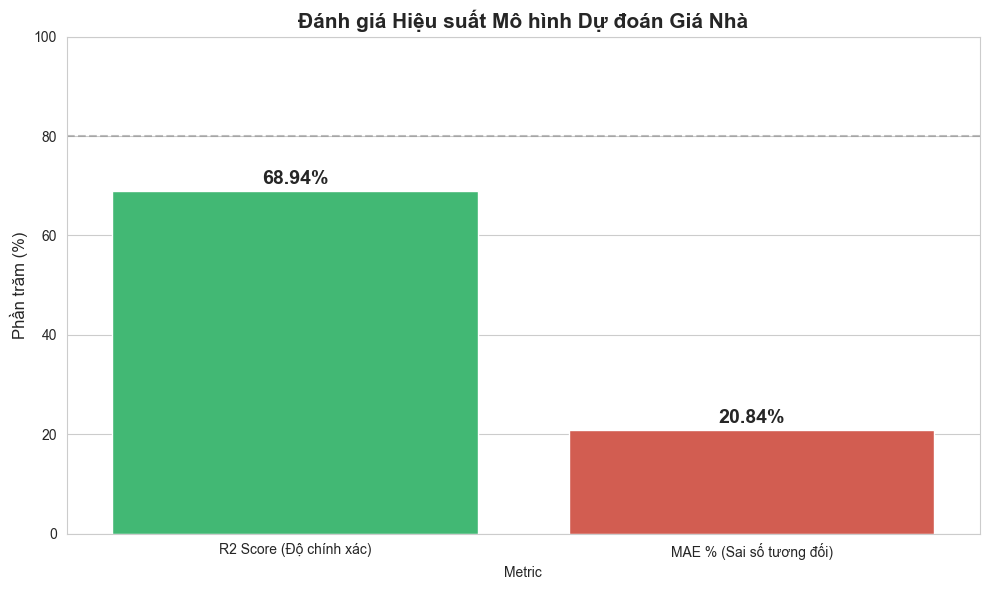

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Dữ liệu từ kết quả Spark của bạn
metrics_data = {
    'Metric': ['R2 Score (Độ chính xác)', 'MAE % (Sai số tương đối)'],
    'Value': [68.94, 20.84],
    'Type': ['Accuracy', 'Error'] # Đánh dấu để tô màu khác nhau
}

df_metrics = pd.DataFrame(metrics_data)

# 2. Thiết lập biểu đồ
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Vẽ biểu đồ cột
# Màu xanh (Accuracy) cho R2, Màu đỏ (Error) cho MAE
colors = ["#2ecc71" if t == "Accuracy" else "#e74c3c" for t in df_metrics['Type']]
ax = sns.barplot(x="Metric", y="Value", data=df_metrics, palette=colors)

# 3. Trang trí
plt.ylim(0, 100) # Thang đo từ 0 đến 100%
plt.ylabel("Phần trăm (%)", fontsize=12)
plt.title("Đánh giá Hiệu suất Mô hình Dự đoán Giá Nhà", fontsize=15, fontweight='bold')

# Thêm đường tham chiếu 80% (mức khá tốt)
plt.axhline(y=80, color='gray', linestyle='--', alpha=0.5)


# Hiển thị số liệu trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

>>> Đang đọc dữ liệu từ: housing_data_cleaned_v3.csv
>>> Đang huấn luyện Random Forest...
>>> Đang huấn luyện Gradient Boosting...

 KẾT QUẢ TRÊN PYTHON (PANDAS + SKLEARN)
 R2 Score: 68.91 %
 MAE:      867.86 Triệu VND
 RMSE:     1,477.85 Triệu VND
 MAPE:     20.84 %


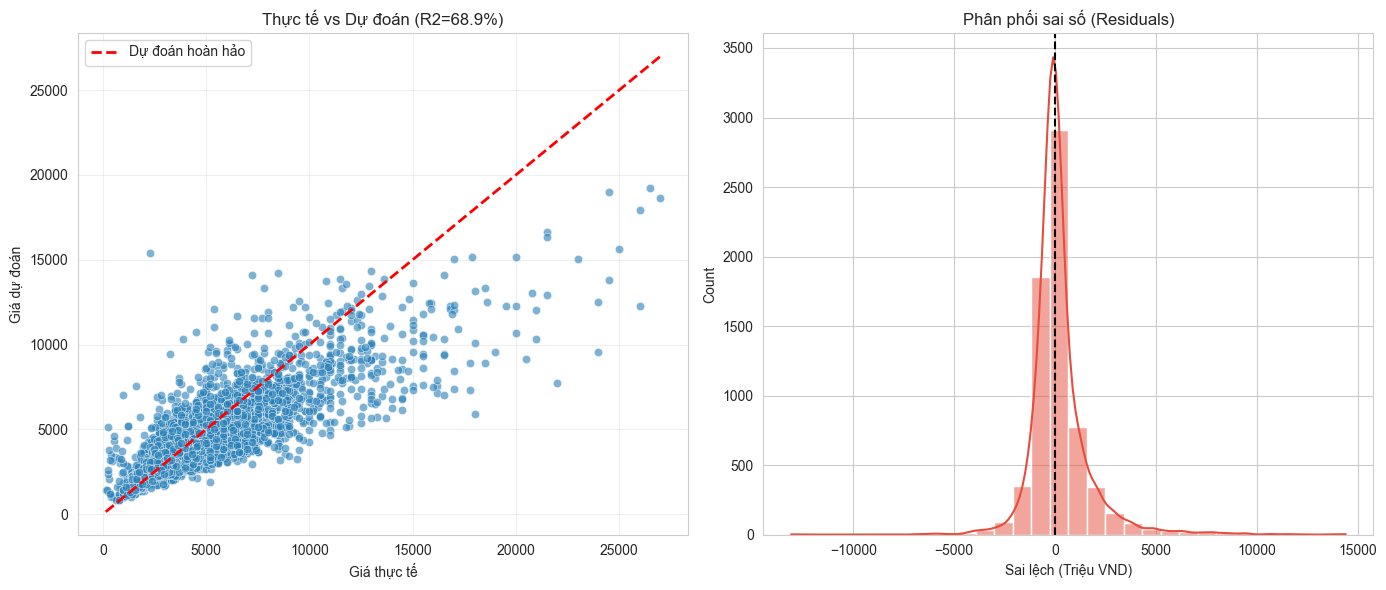

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. ĐỌC DỮ LIỆU
# ---------------------------------------------------------
# Lưu ý: Thay đường dẫn HDFS bằng đường dẫn file local trên máy bạn
path = "housing_data_cleaned_v3.csv" 
print(f">>> Đang đọc dữ liệu từ: {path}")

# Giả lập dữ liệu nếu không có file thật (để code chạy được demo)
# Bạn hãy xóa đoạn này khi chạy file thật
try:
    df = pd.read_csv(path)
except FileNotFoundError:
    print("Không tìm thấy file, tạo dữ liệu giả lập để demo...")
    data = {
        'district': np.random.choice(['Q1', 'Q2', 'Q3'], 1000),
        'ward': np.random.choice(['W1', 'W2', 'W3'], 1000),
        'street': np.random.choice(['S1', 'S2', 'S3'], 1000),
        'type_of_housing': np.random.choice(['House', 'Apartment'], 1000),
        'legal_paper': np.random.choice(['Pink', 'Red'], 1000),
        'num_floors': np.random.randint(1, 5, 1000),
        'num_bed_rooms': np.random.randint(1, 5, 1000),
        'squared_meter_area': np.random.randint(30, 150, 1000),
        'price_in_million_per_square_meter': np.random.randint(50, 200, 1000)
    }
    df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. XỬ LÝ DỮ LIỆU
# ---------------------------------------------------------
# Tạo cột mục tiêu
df["total_price"] = df["squared_meter_area"] * df["price_in_million_per_square_meter"]
df["label_log"] = np.log1p(df["total_price"])

# Lọc nhiễu (Outlier Removal) dùng IQR
def remove_outliers(dframe, col):
    q1 = dframe[col].quantile(0.05)
    q3 = dframe[col].quantile(0.95)
    iqr = q3 - q1
    return dframe[(dframe[col] >= q1 - 0.5 * iqr) & (dframe[col] <= q3 + 0.5 * iqr)]

df_clean = remove_outliers(df, "price_in_million_per_square_meter")
df_clean = remove_outliers(df_clean, "squared_meter_area")

# Chia tập Train/Test (80-20)
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. ENCODING (Target Encoding có làm mượt - Smoothing)
# ---------------------------------------------------------
cat_cols = ['district', 'ward', 'street', 'type_of_housing', 'legal_paper']
num_cols = ['num_floors', 'num_bed_rooms', 'squared_meter_area']
ALPHA = 10
global_mean = train_df['label_log'].mean()

encoding_maps = {}

# Tính toán map trên tập TRAIN
for col in cat_cols:
    stats = train_df.groupby(col)['label_log'].agg(['sum', 'count'])
    # Công thức làm mượt giống code Spark
    smoothed_map = (stats['sum'] + global_mean * ALPHA) / (stats['count'] + ALPHA)
    encoding_maps[col] = smoothed_map

# Hàm áp dụng encoding
def apply_encoding(dframe, maps, cat_columns, glo_mean):
    df_out = dframe.copy()
    for c in cat_columns:
        # Map giá trị, nếu không thấy (xuất hiện mới trong test) thì điền global_mean
        df_out[c + '_encoded'] = df_out[c].map(maps[c]).fillna(glo_mean)
    return df_out

train_encoded = apply_encoding(train_df, encoding_maps, cat_cols, global_mean)
test_encoded = apply_encoding(test_df, encoding_maps, cat_cols, global_mean)

# Chuẩn bị Features (X) và Label (y)
features_col = [c + "_encoded" for c in cat_cols] + num_cols
X_train = train_encoded[features_col]
y_train = train_encoded['label_log']
X_test = test_encoded[features_col]
y_test = test_encoded['label_log']
y_test_real = test_encoded['total_price'] # Giá thực tế để so sánh sau cùng

# ---------------------------------------------------------
# 4. TRAINING (Random Forest & GBT)
# ---------------------------------------------------------
print(">>> Đang huấn luyện Random Forest...")
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(">>> Đang huấn luyện Gradient Boosting...")
gbt = GradientBoostingRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42)
gbt.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. DỰ ĐOÁN & ENSEMBLE
# ---------------------------------------------------------
p_rf = rf.predict(X_test)
p_gbt = gbt.predict(X_test)

# Trọng số: 0.6 RF + 0.4 GBT
avg_log = p_rf * 0.6 + p_gbt * 0.4
pred_real = np.expm1(avg_log) # Chuyển log về giá tiền thực

# ---------------------------------------------------------
# 6. ĐÁNH GIÁ (Evaluation)
# ---------------------------------------------------------
r2 = r2_score(y_test_real, pred_real)
mae = mean_absolute_error(y_test_real, pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test_real - pred_real) / y_test_real)) * 100

print(f"\n{'='*50}")
print(f" KẾT QUẢ TRÊN PYTHON (PANDAS + SKLEARN)")
print(f"{'='*50}")
print(f" R2 Score: {r2*100:.2f} %")
print(f" MAE:      {mae:,.2f} Triệu VND")
print(f" RMSE:     {rmse:,.2f} Triệu VND")
print(f" MAPE:     {mape:.2f} %")

# ---------------------------------------------------------
# 7. VẼ BIỂU ĐỒ (VISUALIZATION)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Biểu đồ 1: Thực tế vs Dự đoán
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_real, y=pred_real, alpha=0.6, color='#2980b9')
# Đường chéo tham chiếu
m_max = max(y_test_real.max(), pred_real.max())
m_min = min(y_test_real.min(), pred_real.min())
plt.plot([m_min, m_max], [m_min, m_max], 'r--', lw=2, label='Dự đoán hoàn hảo')
plt.title(f'Thực tế vs Dự đoán (R2={r2*100:.1f}%)')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.legend()
plt.grid(True, alpha=0.3)

# Biểu đồ 2: Phân phối sai số
plt.subplot(1, 2, 2)
residuals = y_test_real - pred_real
sns.histplot(residuals, kde=True, color='#e74c3c', bins=30)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Phân phối sai số (Residuals)')
plt.xlabel('Sai lệch (Triệu VND)')

plt.tight_layout()
plt.show()


>>> BẢNG SO SÁNH 5 DÒNG ĐẦU TIÊN:
       Giá Thực Tế  Giá Dự Đoán  Chênh lệch  Sai số (%)
8085       3099.84      4075.67     -975.83       31.48
15311      2399.85      2572.90     -173.05        7.21
34975      3550.15      5054.19    -1504.04       42.37
11208      2199.90      2911.19     -711.29       32.33
1741       9700.00      5473.44     4226.56       43.57


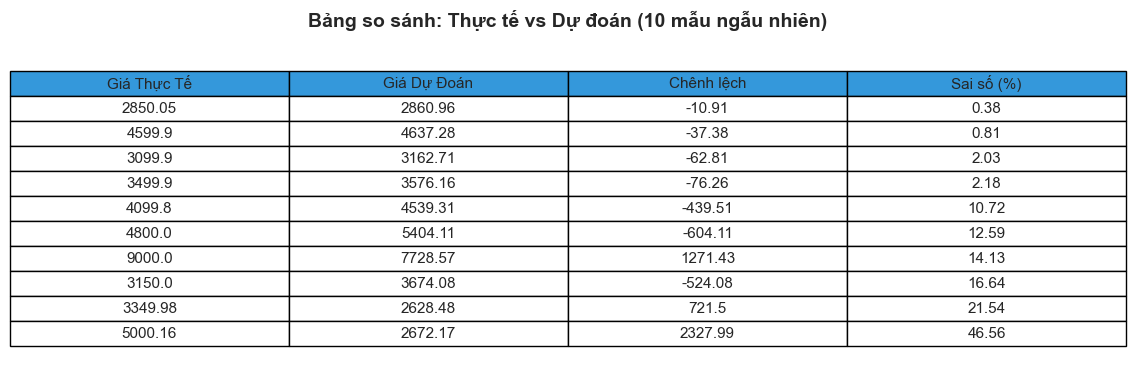

In [8]:
# ... (Tiếp nối code phần trước sau khi đã có y_test_real và pred_real) ...

# ---------------------------------------------------------
# 8. TẠO BẢNG SO SÁNH CHI TIẾT
# ---------------------------------------------------------
# Tạo DataFrame so sánh
compare_df = pd.DataFrame({
    'Giá Thực Tế': y_test_real,
    'Giá Dự Đoán': pred_real
})

# Tính thêm sai số để bảng nhìn có ý nghĩa hơn
compare_df['Chênh lệch'] = compare_df['Giá Thực Tế'] - compare_df['Giá Dự Đoán']
compare_df['Sai số (%)'] = (compare_df['Chênh lệch'].abs() / compare_df['Giá Thực Tế']) * 100

# Làm tròn số cho đẹp
compare_df = compare_df.round(2)

# Lấy 10 mẫu ngẫu nhiên để hiển thị lên bảng (chứ không vẽ hết hàng ngàn dòng)
sample_table = compare_df.sample(10, random_state=42).sort_values(by='Sai số (%)')

# ---------------------------------------------------------
# 9. VẼ BẢNG RA HÌNH ẢNH (Matplotlib)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4)) # Kích thước khung hình

# Tắt trục tọa độ (axis) vì ta chỉ vẽ bảng
ax.axis('off')
ax.set_title("Bảng so sánh: Thực tế vs Dự đoán (10 mẫu ngẫu nhiên)", fontsize=14, fontweight='bold', pad=20)

# Tạo bảng
table = ax.table(
    cellText=sample_table.values, 
    colLabels=sample_table.columns, 
    cellLoc='center', 
    loc='center',
    colColours=["#3498db"] * 4 # Tô màu xanh cho tiêu đề cột
)

# Trang trí bảng
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5) # Chỉnh độ rộng/cao của ô

# In ra màn hình console để xem nhanh
print("\n>>> BẢNG SO SÁNH 5 DÒNG ĐẦU TIÊN:")
print(compare_df.head(5).to_string())

plt.show()

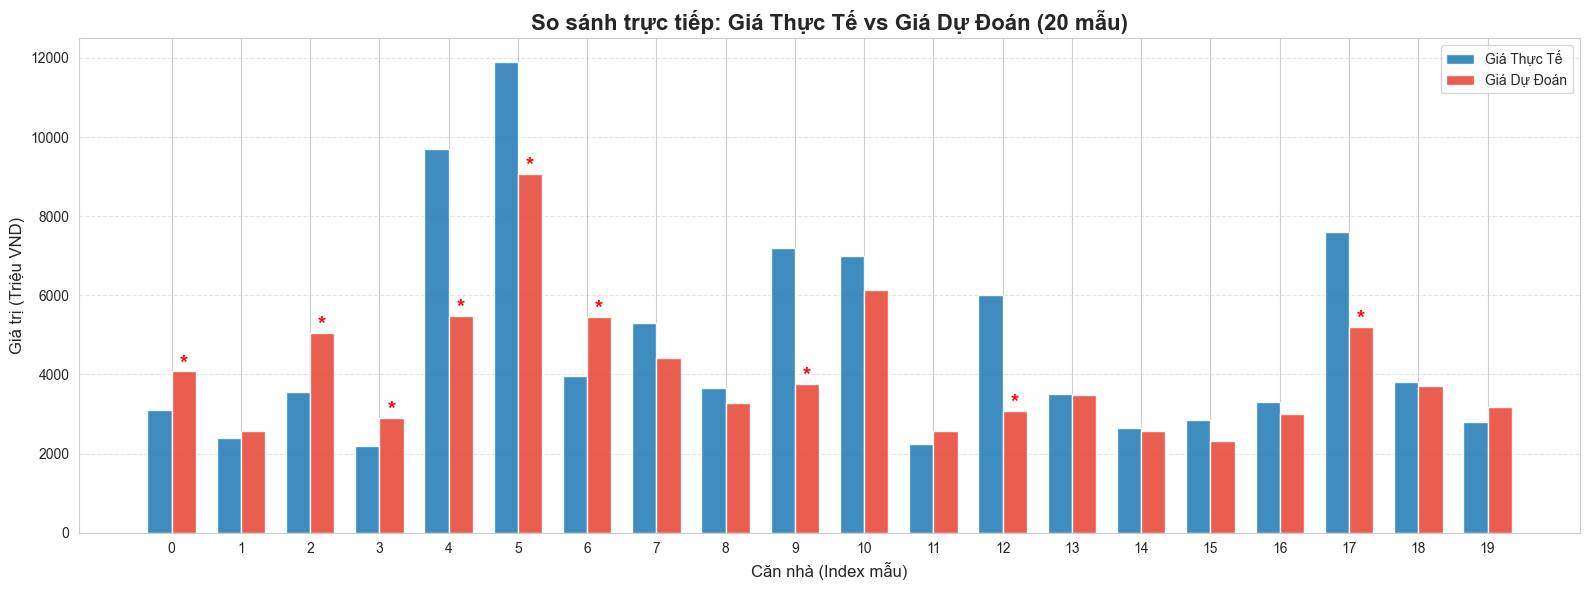

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Giả sử bạn đã có DataFrame 'compare_df' từ bước trước
# (Gồm cột: 'Giá Thực Tế', 'Giá Dự Đoán')

# 1. Lấy mẫu 20 căn nhà đầu tiên để vẽ cho rõ
# reset_index để trục hoành hiện số thứ tự 0, 1, 2...
df_subset = compare_df.head(20).reset_index(drop=True)

# 2. Vẽ biểu đồ cột ghép (Side-by-side Bar Chart)
plt.figure(figsize=(16, 6))

# Vẽ cột cho Giá Thực Tế (vị trí lệch trái một chút)
bar_width = 0.35
index = df_subset.index

plt.bar(index, df_subset['Giá Thực Tế'], bar_width, label='Giá Thực Tế', color='#2980b9', alpha=0.9)

# Vẽ cột cho Giá Dự Đoán (vị trí lệch phải một chút)
plt.bar(index + bar_width, df_subset['Giá Dự Đoán'], bar_width, label='Giá Dự Đoán', color='#e74c3c', alpha=0.9)

# 3. Trang trí biểu đồ
plt.xlabel('Căn nhà (Index mẫu)', fontsize=12)
plt.ylabel('Giá trị (Triệu VND)', fontsize=12)
plt.title('So sánh trực tiếp: Giá Thực Tế vs Giá Dự Đoán (20 mẫu)', fontsize=16, fontweight='bold')
plt.xticks(index + bar_width / 2, index) # Đặt số thứ tự vào giữa 2 cột
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# (Tùy chọn) Hiển thị giá trị chênh lệch lên đầu cột dự đoán
for i in index:
    # Lấy giá trị
    real = df_subset['Giá Thực Tế'][i]
    pred = df_subset['Giá Dự Đoán'][i]
    
    # Nếu sai số lớn (>20%) thì đánh dấu sao (*) để chú ý
    diff_percent = abs(real - pred) / real
    if diff_percent > 0.2:
        plt.text(i + bar_width, pred + 50, '*', ha='center', color='red', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()